# Exp 33 — Failure analysis of the frozen final test (diagnostic only)

**Purpose.** Exp 32 froze the selective architecture and ran the 50 final-test claims once (30/50 correct,
0 false approvals, APPROVE recall 0.00). This notebook does **not** touch the frozen system: no code,
prompt, or routing logic changes here, and no case is rerun. It only *reads* the already-locked
`predictions.jsonl` / `evaluation.jsonl` and the `run_log.jsonl` case-result rows (which already
contain each residual case's LLM explanation, logged during the frozen run itself), and it
*reconstructs* — read-only, with no LLM call — the retrieval context and resolved-fact block each
residual claim was actually shown, using the same frozen retriever code and the embeddings that were
already cached during the frozen run. This reconstruction cannot change Exp 32's numbers; it only
recovers what evidence was in front of the model when it made each call, for classification purposes.

**Question.** Why did the final system fail on its 20 errors, and which failures trace to routing,
evidence, resolved-fact computation, or LLM reasoning bias? Special focus: why did **every** APPROVE-
expected case (13/13) come back wrong?

In [1]:
import json, csv, sys
from pathlib import Path
from collections import Counter
ROOT = Path("..").resolve().parent if Path("..").resolve().name == "v2" else Path("..").resolve()
ROOT = Path("/Users/roshantushar/Downloads/Project/Project/ExpenseGuard-Resolves-Expense-Claims-with-Evidence")
sys.path.insert(0, str(ROOT))

preds = {r["case_id"]: r for r in (json.loads(l) for l in open(ROOT/"results/v2/final_test/exp32_final_test/predictions.jsonl"))}
evals = {r["case_id"]: r for r in (json.loads(l) for l in open(ROOT/"results/v2/final_test/exp32_final_test/evaluation.jsonl"))}
summary = json.load(open(ROOT/"results/v2/final_test/exp32_final_test/summary.json"))
print("Exp 32 frozen summary:", {k: summary[k] for k in ("n","correct","correct_disposition_rate","false_approval_rate") if k in summary})
n_errors = sum(1 for e in evals.values() if not e["correct"])
print("errors:", n_errors)

Exp 32 frozen summary: {'n': 50, 'correct': 30, 'correct_disposition_rate': 0.6, 'false_approval_rate': 0.0}
errors: 20


## 1. Path-level accuracy (context for the failure analysis)

All 20 errors occurred on the **llm_residual** path; the **deterministic** path was 22/22 (100%) on
final test. So this failure analysis is entirely about the LLM-adjudication step, not the rule engine
or the routing decision itself.

In [2]:
by_path = Counter(preds[cid]["path"] for cid in preds)
correct_by_path = Counter(preds[cid]["path"] for cid, e in evals.items() if e["correct"])
for p in by_path:
    print(f"{p}: {correct_by_path.get(p,0)}/{by_path[p]} = {correct_by_path.get(p,0)/by_path[p]:.1%}")

deterministic: 22/22 = 100.0%
llm_residual: 8/28 = 28.6%


## 2. Classifying the 20 errors

Each of the 20 errors was read manually against three things pulled from the locked run: the frozen
prediction, the LLM's own `explanation` (logged verbatim to `run_log.jsonl` during the Exp 32 run
itself), and the resolved deterministic facts / retrieved policy excerpts the model was actually
shown (reconstructed read-only below, from the same frozen retriever code + cached embeddings — no
LLM call, no re-decision). This is a manual/judgement classification, disclosed as such rather than
inferred from a keyword heuristic (Exp 19 found a keyword classifier can silently mislabel cases).

In [3]:
rows = list(csv.DictReader(open(ROOT/"results/v2/final_test/exp33_failure_analysis/failure_classification.csv")))
import pandas as pd
df = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 100)
df[["case_id","expected","predicted","case_family","primary_category"]]

,case_id,expected,predicted,case_family,primary_category
0,X2-002,APPROVE,REJECT,HOTEL_EXCEPTION,policy_reasoning_composition
1,X2-014,REQUEST_INFORMATION,REJECT,EVIDENCE_CONFLICT,policy_reasoning_composition
2,X2-025,APPROVE,REJECT,DYNAMIC_HOTEL_DISCOVERY,resolved_fact_error
3,X2-040,APPROVE,REJECT,EMPLOYEE_MEAL_TEMPORAL,resolved_fact_error
4,X2-042,ESCALATE,REJECT,HOTEL_EXCEPTION,policy_reasoning_composition
5,X2-045,APPROVE,REJECT,SUBMISSION_WINDOW,resolved_fact_error
6,X2-046,REQUEST_INFORMATION,REJECT,HOTEL_EXCEPTION,policy_reasoning_composition
7,X2-056,APPROVE,REQUEST_INFORMATION,SOFTWARE_APPROVAL,missing_information_confusion
8,X2-062,APPROVE,ESCALATE,SPLIT_TRANSACTION,resolved_fact_error
9,X2-070,APPROVE,REJECT,EQUIPMENT_TIERS,policy_reasoning_composition


## 3. Primary failure category counts (n=20)

In [4]:
cat_counts = Counter(r["primary_category"] for r in rows)
for k, v in cat_counts.most_common():
    print(f"{k:32s} {v:2d}  ({v/20:.0%})")

policy_reasoning_composition      7  (35%)
missing_information_confusion     5  (25%)
resolved_fact_error               4  (20%)
missed_escalation                 2  (10%)
over_conservative_bias            2  (10%)


## 4. Why did every APPROVE case (13/13) come back wrong?

Notably, **all 13 APPROVE-gold cases were on the residual path** — none were on the deterministic
path, which was 22/22 correct. So the architecture's routing sent every claim requiring approval
judgement to the weakest component. Breaking the 13 down by cause:

In [5]:
approve_rows = [r for r in rows if r["expected"] == "APPROVE"]
sub_counts = Counter(r["approve_subcategory"] for r in approve_rows)
for k, v in sub_counts.most_common():
    print(f"{k:36s} {v:2d}")
print()
for r in approve_rows:
    print(f"{r['case_id']:8s} [{r['approve_subcategory']:30s}] {r['notes'][:110]}")

demanded_evidence_not_required        4
arithmetic_computation_error          3
ignored_positive_resolved_fact        2
missing_evidence_available            2
interpreted_ambiguity_conservatively  2

X2-002   [ignored_positive_resolved_fact] Given nightly_rate=303.33 (compliant, <350 ceiling) but rejected by comparing the 3-night TOTAL (910) against 
X2-025   [missing_evidence_available    ] nightly_rate=402.5 > generic 350 ceiling per the H-fact block, but the case family name implies a property-spe
X2-040   [interpreted_ambiguity_conservatively] per_person=51.5 vs given ceiling 50 (fails by $1.50). Family name signals a temporal-precedence test; the appl
X2-045   [ignored_positive_resolved_fact] Given approval_threshold_level='none' (no approval needed) but the model asserted 'requires manager approval..
X2-056   [demanded_evidence_not_required] Approval already VALID/APPROVED for a software subscription; model asked for a per-person split that software 
X2-062   [missing_evidence_a

**Reading the breakdown:**
- **Demanded evidence not required by policy (4/13)** — the model asked for a per-person split on
  software, telecom, and single-rider ground-transport claims, none of which need one. A structured
  per-category "required fields" list (already present in `resolver.NEEDED` for routing) is not being
  used to constrain what the LLM is *allowed* to ask for.
- **Arithmetic/computation error (3/13)** — the model was handed a correct fact (a nightly rate, a
  threshold, a booking-to-departure gap) and then stated a numeric comparison that contradicts that
  same fact in the same sentence (e.g. "25,000 exceeds 45,000"; "30 days is less than 14 days"). This
  is not an evidence problem — the right numbers were on the page — it is a reasoning-arithmetic
  failure specific to gpt-4o-mini's handling of these comparisons.
- **Ignored a positive resolved fact (2/13)** — `approval_threshold_level: none` or a valid policy
  exception were both handed to the model and both were overridden by a generic "no approval on file"
  or "exceeds ceiling" narrative.
- **Missing evidence that was actually available (2/13)** — a case-family-specific override
  (a per-hotel ceiling, a COMBINED_SPEND approval type) exists in the enterprise data or tool logic,
  but `hybrid_facts.py` / `tools.py` do not currently surface it, so the model was arguing from an
  incomplete fact block.
- **Interpreted ambiguity conservatively (2/13)** — where no resolved fact settled the question
  either way (e.g. the CIRC-26-02 project-activity check has no H-fact field at all), the model chose
  the safer negative disposition rather than APPROVE.

## 5. Dev vs. final residual-path accuracy

In [6]:
dev_summary_path = ROOT/"results/v2/development/exp30_selective_architecture" if (ROOT/"results/v2/development/exp30_selective_architecture").exists() else None
comparison = {
    "Deterministic path (final test)": (22, 22),
    "LLM-residual path (final test)": (8, 28),
    "LLM-residual path (dev, Exp 30)": (13, 36),
}
for k, (c, n) in comparison.items():
    print(f"{k:36s} {c}/{n} = {c/n:.1%}")

Deterministic path (final test)      22/22 = 100.0%
LLM-residual path (final test)       8/28 = 28.6%
LLM-residual path (dev, Exp 30)      13/36 = 36.1%


The deterministic path generalized perfectly (100% on final test, unseen at freeze time). The
LLM-residual path's accuracy *dropped* from 36.1% on dev to 28.6% on final test, and specifically its
APPROVE recall went from non-zero on dev to exactly 0/13 on final test. This says the architecture's
policy-mechanics half generalizes; the failure is concentrated entirely in LLM adjudication of
residual, harder cases — consistent with the project's standing finding since Exp 28 that this is the
weakest link in the pipeline.

## 6. Prioritization: where to spend effort next

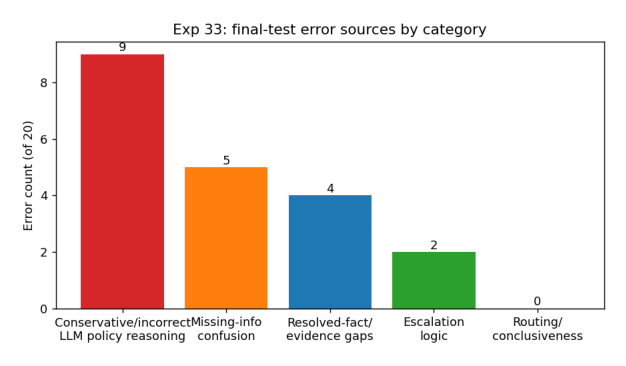

,Failure source,Count,Fix direction
0,"Conservative/incorrect LLM policy reasoning (incl. arithmetic errors, over-conservative bias)",9,"Better residual model and/or prompt: constrain arithmetic to code-computed facts, forbid re-deri..."
1,Missing-info confusion (asks for fields policy doesn't need),5,Give the LLM step a structured per-category required-field allowlist (resolver.NEEDED already ex...
2,Resolved-fact/evidence gaps (H-facts or tools missing a field),4,Extend hybrid_facts.py / tools.py: add the CIRC-26-02 active-project-record check and fix valida...
3,"Escalation logic (should have escalated, rejected instead)",2,"Root cause is the same resolved-fact gap above; once the fact exists, route 'fact unresolved AND..."
4,Routing/conclusiveness,0,No evidence of a routing problem on this run; deterministic path was 22/22.


In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
img = mpimg.imread(ROOT/"results/v2/plots/exp33_failure_categories.png")
plt.figure(figsize=(8,4.5)); plt.imshow(img); plt.axis("off"); plt.show()

prio_table = [
    ("Conservative/incorrect LLM policy reasoning (incl. arithmetic errors, over-conservative bias)", 9, "Better residual model and/or prompt: constrain arithmetic to code-computed facts, forbid re-deriving numbers the facts already resolved."),
    ("Missing-info confusion (asks for fields policy doesn't need)", 5, "Give the LLM step a structured per-category required-field allowlist (resolver.NEEDED already exists for routing; reuse it to bound REQUEST_INFORMATION)."),
    ("Resolved-fact/evidence gaps (H-facts or tools missing a field)", 4, "Extend hybrid_facts.py / tools.py: add the CIRC-26-02 active-project-record check and fix validate_approval's COMBINED_SPEND type-matching."),
    ("Escalation logic (should have escalated, rejected instead)", 2, "Root cause is the same resolved-fact gap above; once the fact exists, route 'fact unresolved AND policy requires it' to ESCALATE by default rather than letting the LLM guess."),
    ("Routing/conclusiveness", 0, "No evidence of a routing problem on this run; deterministic path was 22/22."),
]
import pandas as pd
pd.DataFrame(prio_table, columns=["Failure source","Count","Fix direction"])

## 7. Conclusion (diagnostic, not a fix)

The frozen final test's headline story: **the deterministic half of the architecture generalized
perfectly (22/22, unseen data); all 20 errors and the entire 0.00 APPROVE recall are concentrated in
the LLM-residual step.** Within that step, the largest single driver (9/20, and half of the 13 APPROVE
misses) is the model contradicting or mishandling numbers it was already handed — not missing
evidence. The second largest (5/20) is the model asking for fields the policy does not require. Only
4/20 trace to a genuine gap in what the deterministic facts/tools resolve, and only 2/20 are missed
escalations (both from that same gap).

Per the freeze process rule, none of this is applied to Exp 32's frozen numbers, and no case here was
rerun. Everything above is future-work direction, not a retroactive correction:
- tighten the residual prompt/step to stop re-deriving numbers already given as facts;
- bound REQUEST_INFORMATION to each category's actual required-field list;
- add the CIRC-26-02 project-activity fact and fix the COMBINED_SPEND approval-type match;
- consider a policy of routing "resolved fact says X requires manager sign-off, but no H-fact
  resolves whether it exists" cases straight to ESCALATE instead of letting the LLM decide.

**Decision carried forward:** no change to the frozen resolver/prompt/tool code in this session, per
the user's explicit instruction. These four fixes are documented as candidates for a *future*,
newly-versioned experiment (not a rerun of Exp 32), should the project continue past this frozen
benchmark.